# Capacity Optimization Problem for a Household Network


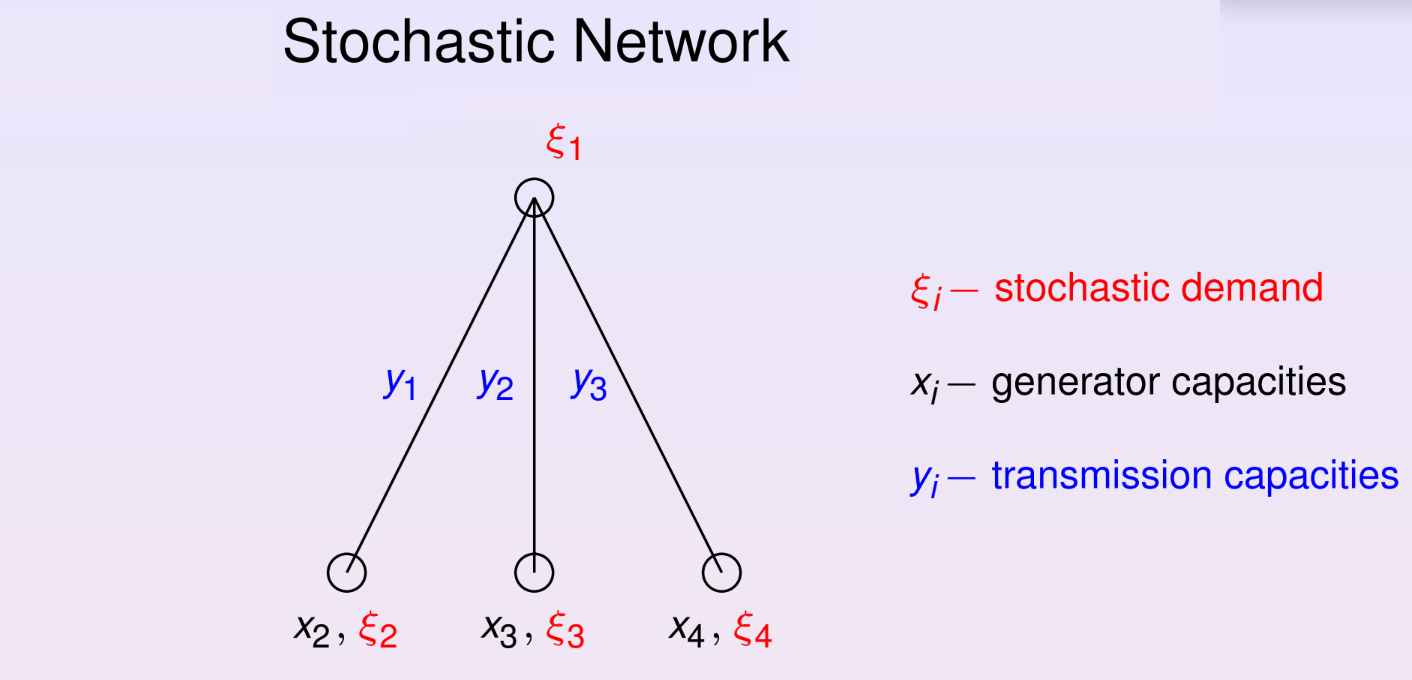

Optimal Generator Capacities (x): [10. 47. 10.]
Optimal Transmission Capacities (y): [-0. 22.  0.]
Minimum Total Cost: 319.0


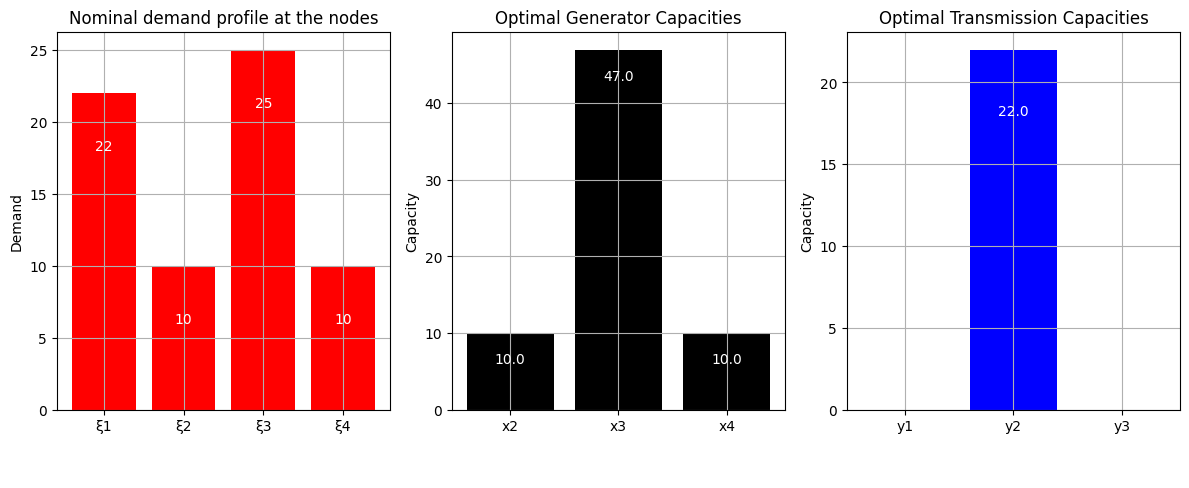

In [3]:
#@title deterministic solution
import numpy as np
from scipy.optimize import linprog
import matplotlib.pyplot as plt

# DATA (update according to your group)
cx = [5, 3, 4] #Cost coefficients for generators (x)  kCHF/pu
cy = [5, 4, 5] # and transmission lines (y) kCHF/pu
c = np.array(cx + cy )  # Corresponds to the costs for (x2, x3, x4, y1, y2, y3)
xi_mean = [22, 10, 25, 10]  # Load demands (deterministic case)

xi = np.array(xi_mean)
min_y, max_y = 0, 100  # per unit power # Bounds: all decision variables are nonnegative.
min_x, max_x = 5, 100  # per unit power
bounds = [(min_x, max_x)] * 3 + [(min_y, max_y)] * 3


# Constraint matrix A_in * a >= b_in
A_in = np.array([
    [ 1,  1,  1,  0,  0,  0],   # Total demand constraint
    [ 0,  0,  0,  1,  1,  1],   # Node 1 in-flow
    [ 1,  0,  0,  1,  0,  0],   # Node 2 in-flow + gen
    [ 0,  1,  0,  0,  1,  0],   # Node 3 in-flow + gen
    [ 0,  0,  1,  0,  0,  1],   # Node 4 in-flow + gen
    [ -1,  0,  0, 1,  0,  0],   #  line capacity 1
    [ 0,  -1,  0,  0, 1,  0],   #  line capacity 2
    [ 0,  0,  -1,  0, 0,  1],   #  line capacity 3
])

# Right-hand side constraints
b_in = np.array([np.sum(xi), # Total demand constraint
                    xi[0],  # Node 1 in-flow
                    xi[1],
                    xi[2],
                    xi[3],  # Nodes 2,3,4 in-flow + gen
                    -xi[1],
                    -xi[2],
                    -xi[3]]) # Lines 1,2,3 capacity

# -------------------------
# SOLVE THE deterministic LP
# -------------------------
result = linprog(c,
                 A_ub=-A_in,
                 b_ub=-b_in,
                 bounds=bounds)

if result.success:
    det_opt = result.x
    optimal_x = det_opt[:3]
    optimal_y = det_opt[3:]
    print("Optimal Generator Capacities (x):", optimal_x)
    print("Optimal Transmission Capacities (y):", optimal_y)
    print("Minimum Total Cost:", result.fun)
else:
    print("Optimization failed:", result.message)


# -------------------------
# PLOT THE SOLUTION
# -------------------------
labels_gen = ['x2', 'x3', 'x4']
labels_trans = ['y1', 'y2', 'y3']
labels_demand = ['ξ1','ξ2', 'ξ3', 'ξ4']
DIS = 4
plt.figure(figsize=(12,5))
plt.subplot(1,3,1)
plt.bar(labels_demand, xi, color='red')
for i, v in enumerate(xi):
    plt.text(i, v -DIS, str(v), ha='center', color='white') # add number on the bar
plt.title("Nominal demand profile at the nodes")
plt.ylabel("Demand")
plt.grid()

plt.subplot(1,3,2)
plt.bar(labels_gen, optimal_x, color='black')
for i, v in enumerate(optimal_x):
    plt.text(i, v -DIS, str(v), ha='center', color='white') # add number on the bar
plt.title("Optimal Generator Capacities")
plt.ylabel("Capacity")
plt.grid()

plt.subplot(1,3,3)
plt.bar(labels_trans, optimal_y, color='blue')
for i, v in enumerate(optimal_y):
    plt.text(i, v -DIS, str(v), ha='center', color='white') # add number on the bar
plt.title("Optimal Transmission Capacities")
plt.ylabel("Capacity")
plt.grid()
plt.tight_layout()
plt.show()


In [16]:
import pandas as pd

url_design = "https://raw.githubusercontent.com/supsi-dacd-isaac/TeachDecisionMakingUncertainty/refs/heads/main/group_work/stochastic_network_design/demand_data_task2_and_3.csv"
url_val = "https://raw.githubusercontent.com/supsi-dacd-isaac/TeachDecisionMakingUncertainty/refs/heads/main/group_work/stochastic_network_design/demand_data_task4_validation.csv"

url_design_G5 = "https://raw.githubusercontent.com/supsi-dacd-isaac/TeachDecisionMakingUncertainty/refs/heads/main/group_work/stochastic_network_design/data/generated_loadsG5_tasks_2_3.csv"
url_val_G5 = "https://raw.githubusercontent.com/supsi-dacd-isaac/TeachDecisionMakingUncertainty/refs/heads/main/group_work/stochastic_network_design/data/generated_loadsG5_validation.csv"

url_design_G6 = "https://raw.githubusercontent.com/supsi-dacd-isaac/TeachDecisionMakingUncertainty/refs/heads/main/group_work/stochastic_network_design/data/generated_loadsG6_tasks_2_3.csv"
url_val_G6 = "https://raw.githubusercontent.com/supsi-dacd-isaac/TeachDecisionMakingUncertainty/refs/heads/main/group_work/stochastic_network_design/data/generated_loadsG6_validation.csv"

# Load the CSV into a DataFrame
df_tasks_2_3_modelling_and_design = pd.read_csv(url_design)
df_tasks_4_validation = pd.read_csv(url_val)

df_tasks_2_3_modelling_and_design_G5 = pd.read_csv(url_design_G5)
df_tasks_4_validation_G5 = pd.read_csv(url_val_G5)

df_tasks_2_3_modelling_and_design_G6 = pd.read_csv(url_design_G6)
df_tasks_4_validation_G6 = pd.read_csv(url_val_G6)



# Display the first few rows
df_tasks_2_3_modelling_and_design_G6.head()

df_tasks_4_validation_G6.head()


,Unnamed: 0,node_1,node_2,node_3,node_4
0,0,8.668430,2.913993,9.699418,3.546191
1,1,13.827761,5.007954,15.248267,5.449358
2,2,8.496903,1.711215,7.722318,1.605829
3,3,6.481751,3.763061,7.363018,3.894064
4,4,7.661209,6.071200,8.588504,6.385080


# Let see if we can run a robust optimization example

In [17]:
!pip install rsome
!pip install mosek
!rm mosek.lic
!git clone https://github.com/roberock/mosek_lic
!cp ./mosek_lic/mosek.lic .
!rm -r ./mosek_lic
!mkdir -p /root/mosek
!cp ./mosek.lic /root/mosek
#!pip install -i https://pypi.gurobi.com gurobipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 93.2 MB/s eta 0:00:00
rm: cannot remove 'mosek.lic': No such file or directory
Cloning into 'mosek_lic'...
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (5/5), done.
Receiving objects: 100% (7/7), done.
remote: Total 7 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)


In [18]:
import numpy as np
import rsome as rso
from rsome import ro
from rsome import msk_solver as my_solver   # Import Mosek solver interface
#from rsome import grb_solver as my_solver  # Import Gurobi solver interface

In [19]:
from re import U
#Create model
model = ro.Model('robust_stochastic_network')
 # Define decision variables
x2 = model.dvar()              # Define capacity decision for gen on nodes 2,3,4
x3 = model.dvar()              #
x4 = model.dvar()              #
y1 = model.dvar()              # Define capacity decision for the lines 1, 2, 3
y2 = model.dvar()              #
y3 = model.dvar()              #

#######
# Objective to maximize the profit
#######

# Cost coefficients
objective_fun = c[0]*x2 + c[1]*x3 +c[2]*x4 + c[3]*y1 + c[4]*y2 + c[5]*y3

# Set the objective function to be minimized
model.min(objective_fun) # This line is added to set the objective

# Declare uncertain parameters and the box uncertainty set
u = model.rvar(4)            # define 4 random variables
Gamma =  200
boxSet = (abs(u) <=1,   # each variable is in a box [-1, 1]
          rso.norm(u, 1) <= Gamma);       # here we have a budgetted constraint

error_level= 0.3  #30 % error


#######
## Constraints

# List of constraints (each as (A_row, b_value)):
constraints = []

# Constraints that decision variables

for var_yi in [y1,y2,y3]:
  model.st(var_yi <= max_y)           #  non-negative
  model.st(var_yi >= min_y)           #  non-negative

for var_xi in [x2,x3,x4]:
  model.st(var_xi<= max_x)           #
  model.st(var_xi>= min_x)           #


model.st( (x2 + x3 + x4 >= xi_mean[0]*(1+error_level*u[0]) + xi_mean[1]*(1+error_level*u[1]) + xi_mean[2]*(1+error_level*u[2]) +xi_mean[3]*(1+error_level*u[3])).forall(boxSet) )
model.st( (y1 + y2 + y3 >= xi_mean[0]*(1+error_level*u[0])).forall(boxSet) )

model.st( (x2 + y1 >= xi_mean[1]*(1+error_level*u[1]) ).forall(boxSet) )
model.st( (x3 + y2 >= xi_mean[2]*(1+error_level*u[2]) ).forall(boxSet) )
model.st( (x4 + y3 >= xi_mean[3]*(1+error_level*u[3])).forall(boxSet) )

model.st( (y1 >= x2 - xi_mean[1]*(1+error_level*u[1]) ).forall(boxSet) )
model.st( (y2 >= x3 - xi_mean[2]*(1+error_level*u[2]) ).forall(boxSet) )
model.st( (y3 >= x4 - xi_mean[3]*(1+error_level*u[3])).forall(boxSet) )

# solve the model
model.solve(my_solver)

# Retrieve optimal results
optobj_rob = model.get()  # Optimal objective value
rob_sol_x2 = x2.get()
rob_sol_x3 = x3.get()
rob_sol_x4 = x4.get()
rob_sol_y1 = y1.get()
rob_sol_y2 = y2.get()
rob_sol_y3 = y3.get()

rob_sol_x = [rob_sol_x2,rob_sol_x3,rob_sol_x4]
rob_sol_y = [rob_sol_y1,rob_sol_y2,rob_sol_y3]

# Print the solution
print(f"Optimal RO Cost: {optobj_rob:.2f}")
print(f"Optimal RO x: {rob_sol_x2:.2f}, x3: {rob_sol_x3:.2f}, x4: {rob_sol_x4:.2f}")
print(f"Optimal RO y: {rob_sol_y1:.2f}, y2: {rob_sol_y2:.2f}, y3: {rob_sol_y3:.2f}")


Being solved by Mosek...
Solution status: Optimal
Running time: 0.0604s
Optimal RO Cost: 519.70
Optimal RO x: 10.00, x3: 67.10, x4: 10.00
Optimal RO y: 3.00, y2: 49.60, y3: 3.00


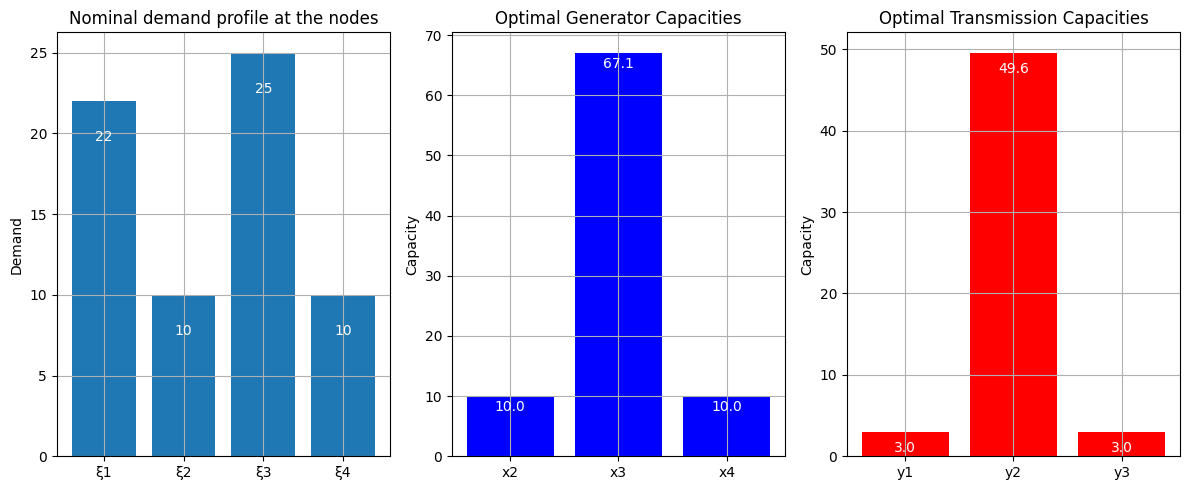

In [ ]:
# -------------------------
# PLOT THE SOLUTION
# -------------------------
labels_gen = ['x2', 'x3', 'x4']
labels_trans = ['y1', 'y2', 'y3']
labels_demand = ['ξ1','ξ2', 'ξ3', 'ξ4']

rob_sol_x = np.array(rob_sol_x).round(2)
rob_sol_y = np.array(rob_sol_y).round(2)

plt.figure(figsize=(12,5))
plt.subplot(1,3,1)
plt.bar(labels_demand, xi)
for i, v in enumerate(xi):
    plt.text(i, v -2.5, str(v), ha='center', color='white') # add number on the bar
plt.title("Nominal demand profile at the nodes")
plt.ylabel("Demand")
plt.grid()

plt.subplot(1,3,2)
plt.bar(labels_gen, rob_sol_x, color='blue')
for i, v in enumerate(rob_sol_x):
    plt.text(i, v -2.5, str(v), ha='center', color='white') # add number on the bar
plt.title("Optimal Generator Capacities")
plt.ylabel("Capacity")
plt.grid()

plt.subplot(1,3,3)
plt.bar(labels_trans, rob_sol_y, color='red')
for i, v in enumerate(rob_sol_y):
    plt.text(i, v -2.5, str(v), ha='center', color='white') # add number on the bar
plt.title("Optimal Transmission Capacities")
plt.ylabel("Capacity")
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
#@title Assuming $\xi_i \sim N(\mu_i,\sigma_i)$
xi_std = 0.1 * np.array(xi_mean)
#get distribution of b constraints:
b_mean = np.array([sum(xi_mean)] + xi_mean + [-xi_mean[1], -xi_mean[2], -xi_mean[3]])  # list of mean values for b_mean

b_std = np.array([
                np.sqrt(np.sum(xi_std**2)),  # std of sum
                *xi_std,                     # std of xi[0:4]
                *xi_std[1:]                 # std of xi[1:4] again for constraints 5 to 7
                 ])

b_cov = np.diag(b_std**2)


In [ ]:
import numpy as np
from scipy.stats import norm
from scipy.stats import multivariate_normal

# Define deterministic inequality matrix
A_det =  np.array([
    [ 1,  1,  1,  0,  0,  0],   # Total demand constraint
    [ 0,  0,  0,  1,  1,  1],   # Node 1 in-flow
    [ 1,  0,  0,  1,  0,  0],   # Node 2 in-flow + gen
    [ 0,  1,  0,  0,  1,  0],   # Node 3 in-flow + gen
    [ 0,  0,  1,  0,  0,  1],   # Node 4 in-flow + gen
    [ -1,  0,  0, 1,  0,  0],   #  line capacity 1
    [ 0,  -1,  0,  0, 1,  0],   #  line capacity 2
    [ 0,  0,  -1,  0, 0,  1],   #  line capacity 3
])

# Right-hand side constraints
b_in =  np.array([np.sum(xi), # Total demand constraint
                    xi[0],  # Node 1 in-flow
                    xi[1],
                    xi[2],
                    xi[3],  # Nodes 2,3,4 in-flow + gen
                    -xi[1],
                    -xi[2],
                    -xi[3]]) # Lines 1,2,3 capacity


capacity_decisions = [rob_sol_x, rob_sol_y]

def chance_model(capacity_decisions, alpha=0.05):
  """ chance constraint for the gaussian linear inequality... """
  mean_transformed =  b_mean - A_det@np.array(capacity_decisions).flatten()
  probability_lower_than_zero = multivariate_normal(mean=mean_transformed, cov =b_cov).cdf([0]*len(b_mean))
  is_feasible_for_alpha = probability_lower_than_zero > 1-alpha
  return probability_lower_than_zero, is_feasible_for_alpha

In [ ]:
alpha_target= 0.05
prob, feasible = chance_model(capacity_decisions = [rob_sol_x, rob_sol_y], alpha=alpha_target)
print('prob', prob)
print(f'is capacity constraint feasible at level {1-alpha_target} ?', feasible)

prob 0.9932686937625893
is capacity constraint feasible at level 0.95 ? True


In [ ]:
n_search = int(1e4)
cost_best_cc = 1e7
alpha_target= 0.01
prob_best_cc = 0
sol_best = np.array([rob_sol_x, rob_sol_y])
count_stuck = 0
new_opt_counter = 0
for n in range(n_search):
   sol_test = np.random.uniform(low=(min_x,min_x,min_x,min_y,min_y,min_y),
                                high=(max_x,max_x,max_x,max_y,max_y,max_y))

   count_stuck+=1
   if count_stuck > 15:
      sol_test = np.random.normal(loc = sol_best, scale = 0.05)

   prob, feasible = chance_model(capacity_decisions = sol_test, alpha=alpha_target)

   cost = c@sol_test
   if feasible and cost<= cost_best_cc:
     cost_best_cc = cost
     count_stuck = 0
     new_opt_counter +=1
     prob_best = prob
     sol_best = sol_test

     if new_opt_counter in range(0,n_search,200):
           print(f'step{n}:')
           print(f'best cost {cost_best_cc} best prob {prob_best}' )
           if new_opt_counter in range(0,n_search,1000):
              [print(f'sol best {si:.1f}' ) for si in sol_best]

print('CC solution:' ,sol_best)
print('CC cost:' ,prob_best_cc)


cc_sol_x = sol_best[:3]
cc_sol_y = sol_best[3:]

# Print the solution
print(f"Optimal CC Cost: {cost_best_cc:.2f}")
print(f"Optimal CC x: {cc_sol_x[0]:.2f}, x3: {cc_sol_x[1]:.2f}, x4: {cc_sol_x[2]:.2f}")
print(f"Optimal CC y: {cc_sol_y[0]:.2f}, y2: {cc_sol_y[1]:.2f}, y3: {cc_sol_y[2]:.2f}")

step3593:
best cost 653.6088679812199 best prob 0.9999459830236033
step6995:
best cost 569.6459275599068 best prob 0.991686041894189
CC solution: [23.78799952 41.63227027 10.69184836 24.97423008 23.51081819  3.75016952]
CC cost: 0
Optimal CC Cost: 524.27
Optimal CC x: 23.79, x3: 41.63, x4: 10.69
Optimal CC y: 24.97, y2: 23.51, y3: 3.75


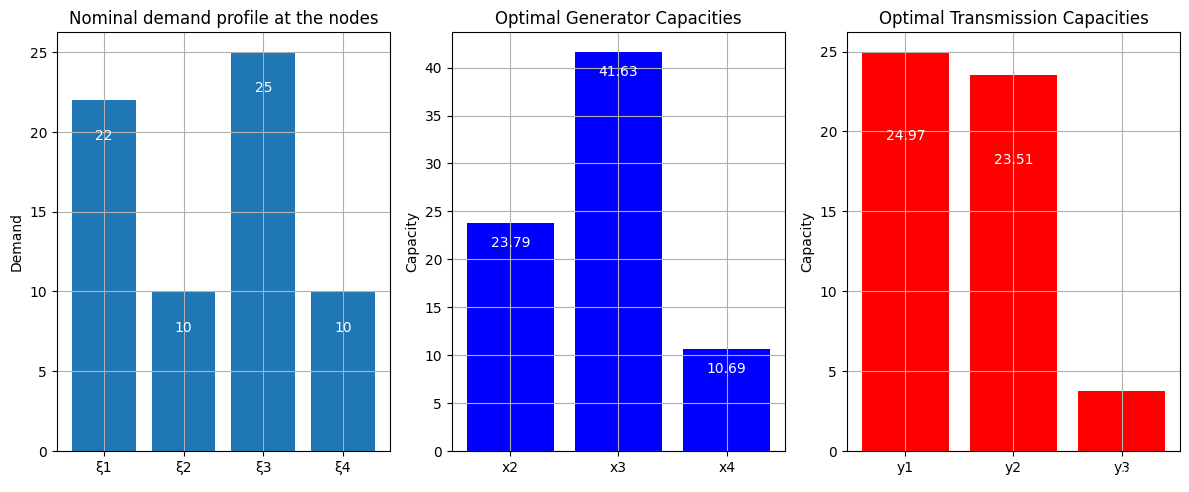

In [ ]:
# -------------------------
# PLOT THE SOLUTION
# -------------------------
labels_gen = ['x2', 'x3', 'x4']
labels_trans = ['y1', 'y2', 'y3']
labels_demand = ['ξ1','ξ2', 'ξ3', 'ξ4']

cc_sol_x = np.array(cc_sol_x).round(2)
cc_sol_y = np.array(cc_sol_y).round(2)

plt.figure(figsize=(12,5))
plt.subplot(1,3,1)
plt.bar(labels_demand, xi)
for i, v in enumerate(xi):
    plt.text(i, v -2.5, str(v), ha='center', color='white') # add number on the bar
plt.title("Nominal demand profile at the nodes")
plt.ylabel("Demand")
plt.grid()

plt.subplot(1,3,2)
plt.bar(labels_gen, cc_sol_x, color='blue')
for i, v in enumerate(cc_sol_x):
    plt.text(i, v -2.5, str(v), ha='center', color='white') # add number on the bar
plt.title("Optimal Generator Capacities")
plt.ylabel("Capacity")
plt.grid()

plt.subplot(1,3,3)
plt.bar(labels_trans, cc_sol_y, color='red')
for i, v in enumerate(cc_sol_y):
    plt.text(i, v -5.5, str(v), ha='center', color='white') # add number on the bar
plt.title("Optimal Transmission Capacities")
plt.ylabel("Capacity")
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

def DGM1(n_samples, xi_mean, xi_std):
  # Generate skewed data using a Gamma distribution
  # Adjust the shape and scale parameters to control skewness
  # You might need to experiment to get the desired level of right skewness
  xi_data_frame = pd.DataFrame()

  for i, (mu, std) in enumerate(zip(xi_mean, xi_std)):
      shape = (mu / std)**2  # Shape parameter for Gamma distribution (related to mean and std)
      scale = std**2 / mu   # Scale parameter

      # Generate skewed data
      data = np.random.gamma(shape, scale, n_samples)

      # Add generated data to the dataframe
      xi_data_frame[i] = data

  xi_data_list = xi_data_frame.values
  return xi_data_list, xi_data_frame



def DGM_fat(n_samples, xi_mean, xi_std):
    """
    Generate data with a fat right tail using a log-normal distribution.

    For each column, the underlying normal distribution is parameterized
    so that the log-normal's mean and standard deviation approximately match
    xi_mean and xi_std. Specifically:

      sigma² = log(1 + (xi_std/xi_mean)²)
      mu = log(xi_mean) - sigma²/2

    Parameters:
      - n_samples: Number of samples to generate.
      - xi_mean: List or array of target means for each variable.
      - xi_std: List or array of target standard deviations for each variable.

    Returns:
      - xi_data_list: Numpy array of generated data.
      - xi_data_frame: DataFrame containing the generated data.
    """
    xi_data_frame = pd.DataFrame()

    for i, (mean_val, std_val) in enumerate(zip(xi_mean, xi_std)):
        # Compute parameters for the underlying normal distribution
        sigma2 = np.log(1 + (std_val / mean_val) ** 2)
        mu = np.log(mean_val) - sigma2 / 2
        sigma = np.sqrt(sigma2)

        # Generate log-normal data which naturally has a fat right tail.
        data = np.random.lognormal(mean=mu, sigma=sigma, size=n_samples)
        xi_data_frame[i] = data

    xi_data_list = xi_data_frame.values
    return xi_data_list, xi_data_frame





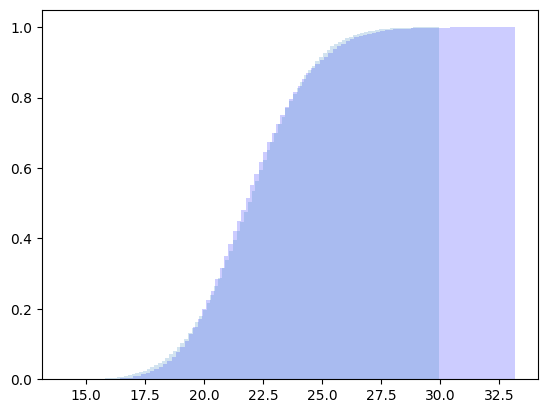

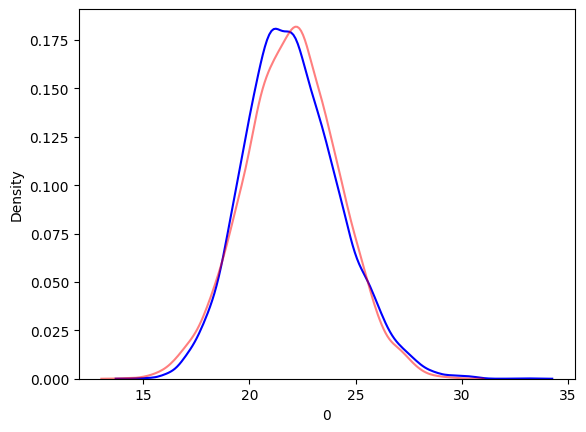

In [ ]:
import seaborn as sns
# Number of samples
n_samples = 10_000
xi_data_list, xi_data_frame = DGM_fat(n_samples, xi_mean, xi_std)

gaussian_samples = np.random.normal(loc=xi_mean, scale=xi_std, size=(n_samples, len(xi_mean)))
plt.hist(xi_data_frame.iloc[:,0],density=True, bins=100, color='b', alpha =0.2, cumulative =True)
plt.hist(pd.DataFrame(gaussian_samples).iloc[:,0],density=True, bins=100, alpha =0.2, cumulative =True)
plt.show()

sns.kdeplot(xi_data_frame.iloc[:,0], color='blue')
sns.kdeplot(pd.DataFrame(gaussian_samples).iloc[:,0], color='red', alpha=0.5)
plt.show()



In [ ]:
def buld_data_driven_problem_inequalities(xi_data_list):
    A_in = []
    b_in = []
    A_det = [
        [ 1,  1,  1,  0,  0,  0],   # Total demand constraint
        [ 0,  0,  0,  1,  1,  1],   # Node 1 in-flow
        [ 1,  0,  0,  1,  0,  0],   # Node 2 in-flow + gen
        [ 0,  1,  0,  0,  1,  0],   # Node 3 in-flow + gen
        [ 0,  0,  1,  0,  0,  1],   # Node 4 in-flow + gen
        [ -1,  0,  0, 1,  0,  0],   #  line capacity 1
        [ 0,  -1,  0,  0, 1,  0],   #  line capacity 2
        [ 0,  0,  -1,  0, 0,  1],]   #  line capacity 3

    for xi_sample in xi_data_list:
        A_in += A_det
        b_sam = [np.sum(xi_sample),   xi_sample[0],   xi_sample[1],
                xi_sample[2],     xi_sample[3],
                -xi_sample[1],     -xi_sample[2],    -xi_sample[3]]

        b_in.append(b_sam)
    return np.array(A_in), np.array(b_in).flatten()


n_samples = 500
xi_data_list, xi_data_frame = DGM_fat(n_samples, xi_mean, xi_std)

A_in, b_in  = buld_data_driven_problem_inequalities(xi_data_list)

# -------------------------
# SOLVE THE deterministic LP
# -------------------------
result = linprog(c,
                 A_ub=-A_in,
                 b_ub=-b_in,
                 bounds=bounds,
                 method="highs")

if result.success:
    data_driven_opt = result.x
    optimal_x = data_driven_opt[:3]
    optimal_y = data_driven_opt[3:]
    print("Optimal Generator Capacities (x):", optimal_x)
    print("Optimal Transmission Capacities (y):", optimal_y)
    print("Minimum Total Cost:", result.fun)
else:
    print("Optimization failed:", result.message)

optimal_x = np.array(optimal_x).round(2)
optimal_y = np.array(optimal_y).round(2)

Optimal Generator Capacities (x): [10.3125161  60.38088373 10.5519915 ]
Optimal Transmission Capacities (y): [ 2.58202864 41.80535769  3.06660982]
Minimum Total Cost: 470.377820772845


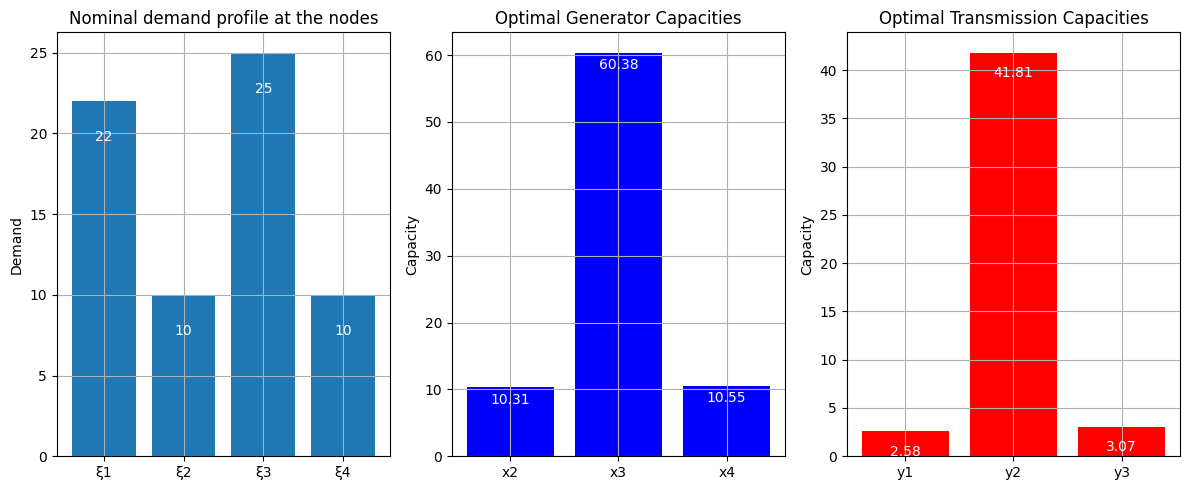

In [ ]:

# -------------------------
# PLOT THE SOLUTION
# -------------------------
labels_gen = ['x2', 'x3', 'x4']
labels_trans = ['y1', 'y2', 'y3']
labels_demand = ['ξ1','ξ2', 'ξ3', 'ξ4']
plt.figure(figsize=(12,5))
plt.subplot(1,3,1)
plt.bar(labels_demand, xi)
for i, v in enumerate(xi):
    plt.text(i, v -2.5, str(v), ha='center', color='white') # add number on the bar
plt.title("Nominal demand profile at the nodes")
plt.ylabel("Demand")
plt.grid()

plt.subplot(1,3,2)
plt.bar(labels_gen, optimal_x, color='blue')
for i, v in enumerate(optimal_x):
    plt.text(i, v -2.5, str(v), ha='center', color='white') # add number on the bar
plt.title("Optimal Generator Capacities")
plt.ylabel("Capacity")
plt.grid()

plt.subplot(1,3,3)
plt.bar(labels_trans, optimal_y, color='red')
for i, v in enumerate(optimal_y):
    plt.text(i, v -2.5, str(v), ha='center', color='white') # add number on the bar
plt.title("Optimal Transmission Capacities")
plt.ylabel("Capacity")
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
def g_fun(solution, A_in, b_in, n_constraints_per_sample=8):
    """
    Computes the constraint violations for a candidate solution.

    For each sample, the inequalities are:
        -A_in[i] * solution + b_in[i] <= 0
    This function calculates these values for all constraints in each sample,
    then computes the maximum violation per sample.

    Parameters:
        solution:    A 1D numpy array representing the candidate solution (e.g., vector of size 6).
        A_in:        A 2D numpy array with shape (n_samples * n_constraints_per_sample, n_vars)
                     containing the constraint coefficients.
        b_in:        A 1D numpy array of length (n_samples * n_constraints_per_sample)
                     containing the right-hand sides of the constraints.
        n_constraints_per_sample: The number of inequalities provided per sample.
                                  (Default is 8 as in the buld_data_driven_problem_inequalities function.)

    Returns:
        overall_max: The maximum violation across all samples.
        sample_max:  A 1D numpy array of length n_samples, where each entry is the maximum violation for that sample.
        violations:  A 2D numpy array of shape (n_samples, n_constraints_per_sample) containing
                     the individual constraint values for each sample.
                     (A positive value indicates a violation.)
    """
    # Determine number of samples from b_in length.
    n_samples = int(len(b_in) / n_constraints_per_sample)

    # Reshape b_in into (n_samples, n_constraints_per_sample)
    b_in_samples = b_in.reshape(n_samples, n_constraints_per_sample)

    # Reshape A_in into (n_samples, n_constraints_per_sample, n_vars)
    A_in_samples = A_in.reshape(n_samples, n_constraints_per_sample, -1)

    # Compute violation for each constraint: violation = -A_in * solution + b_in
    # Using einsum for clarity: for each sample i and constraint j,
    # violation[i,j] = -dot(A_in_samples[i,j,:], solution) + b_in_samples[i,j]
    violations = -np.einsum('ijk,k->ij', A_in_samples, solution) + b_in_samples

    # Maximum violation for each sample (if all are <=0, max_violation will be non-positive)
    sample_max = np.max(violations, axis=1)

    # Overall maximum violation across all samples.
    overall_max = np.max(sample_max)

    return overall_max, sample_max, violations



In [ ]:
# Number of samples
n_samples = 50_000
xi_data_list, xi_data_frame = DGM_fat(n_samples, xi_mean, xi_std)
A_in, b_in  = buld_data_driven_problem_inequalities(xi_data_list)

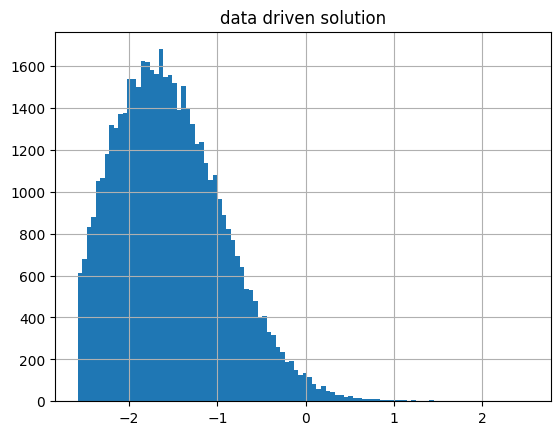

0.0142


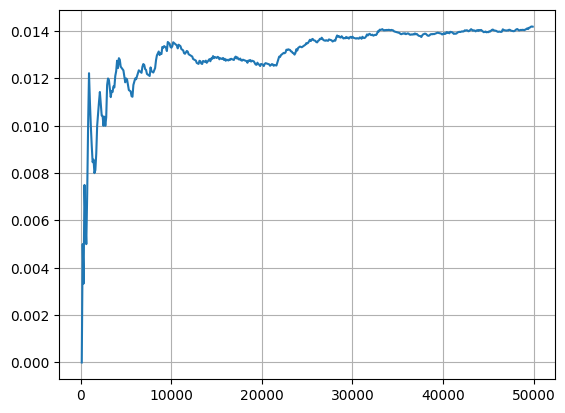

0.0142


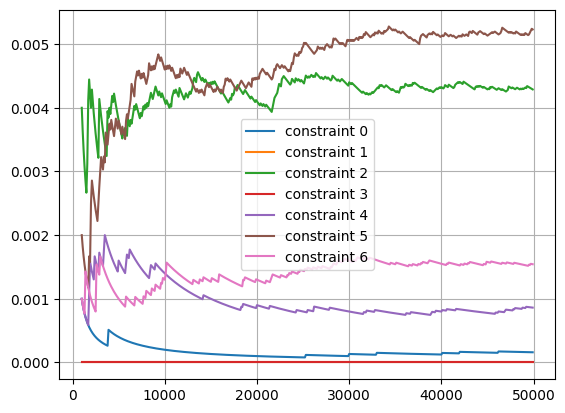

In [ ]:
g_overall_max, g_sample_max, violations = g_fun(data_driven_opt, A_in, b_in, n_constraints_per_sample=8)
violations = pd.DataFrame(violations)

plt.hist(g_sample_max, bins=100)
plt.grid()
plt.title('data driven solution')
plt.show()

print(np.mean(g_sample_max>0))
plt.plot(range(100,len(g_sample_max),100), [np.mean(g_sample_max[:i]>0) for i in range(100,len(g_sample_max),100)])
plt.grid()
plt.show()


print(np.mean(g_sample_max>0))
violations_npy = violations.to_numpy()
for kk in range(7):
  plt.plot(range(1000,len(g_sample_max),100), [np.mean(violations_npy[:i,kk]>0) for i in range(1000,len(g_sample_max),100)], label = f'constraint {kk}')
plt.grid()
plt.legend()
plt.show()

In [ ]:
import pandas as pd

url_val = "https://raw.githubusercontent.com/supsi-dacd-isaac/TeachDecisionMakingUncertainty/refs/heads/main/group_work/stochastic_network_design/demand_data_task4_validation.csv"
url_design = "https://raw.githubusercontent.com/supsi-dacd-isaac/TeachDecisionMakingUncertainty/refs/heads/main/group_work/stochastic_network_design/demand_data_task2_and_3.csv"

# Load the CSV into a DataFrame
df_tasks_4_validation = pd.read_csv(url_val)
df_tasks_2_3_modelling_and_design = pd.read_csv(url_design)


df_tasks_4_validation
df_tasks_2_3_modelling_and_design


,1,2,3,4
0,18.645368,9.158402,26.734796,10.112260
1,22.032234,9.625420,26.649974,10.700635
2,21.736908,10.549740,22.908477,9.689246
3,17.833949,10.401562,23.383460,9.950623
4,26.168801,11.229433,25.427600,10.460829
...,...,...,...,...
95,23.820519,11.091908,23.826393,12.179594
96,20.267862,8.976766,28.876014,12.160038
97,18.818888,9.067854,25.389628,10.836643
98,20.307448,11.237359,26.663823,9.116900


In [ ]:
df_tasks_2_3_modelling_and_design.std()

,0
1,2.234821
2,0.914068
3,2.392885
4,1.020981


In [ ]:
best_cc_solution_list = cc_sol_x.tolist() +cc_sol_y.tolist()
best_ro_solution_list = rob_sol_x.tolist()  + rob_sol_y.tolist()
best_dd_solution_list = data_driven_opt

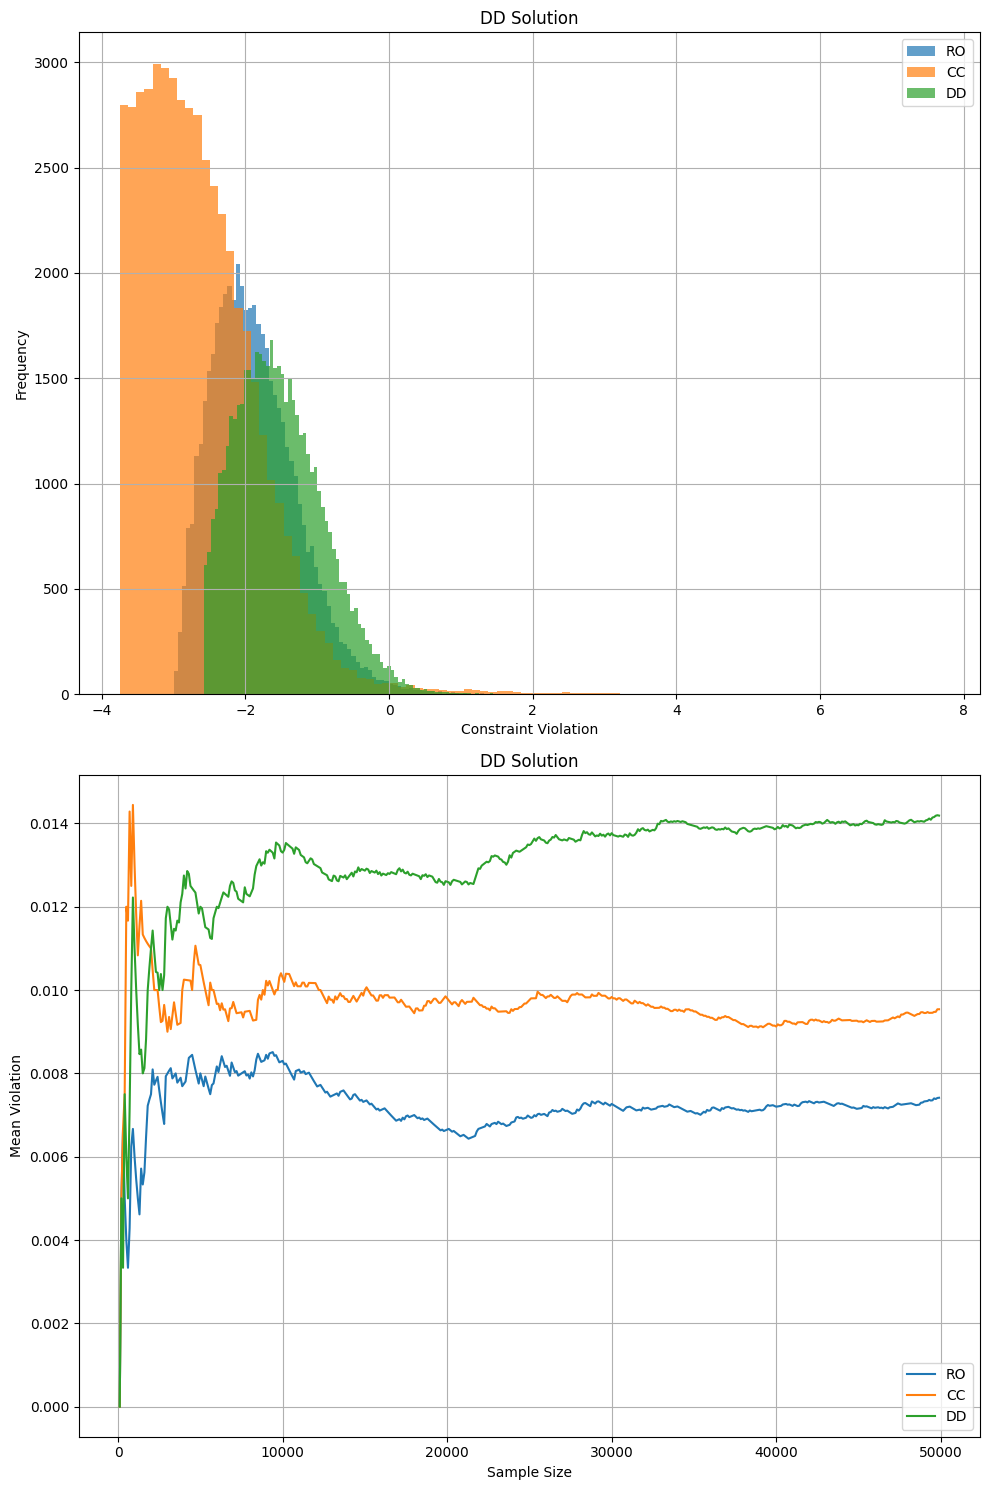

In [ ]:


import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 15))  # 3 rows, 1 column

for sol_unc, name_label in zip([best_ro_solution_list, best_cc_solution_list, best_dd_solution_list], ['RO','CC','DD']):
  g_overall_max, g_sample_max, violations = g_fun(sol_unc, A_in, b_in, n_constraints_per_sample=8)
  violations = pd.DataFrame(violations)
  axes[0].hist(g_sample_max, bins=100, label=name_label, alpha=0.7)
  axes[0].grid()
  axes[0].set_title(f'{name_label} Solution') # Set title for each subplot
  axes[0].legend() # Show the legend for each subplot

  axes[0].set_ylabel('Frequency')
  axes[0].set_xlabel('Constraint Violation')

  axes[1].plot(range(100,len(g_sample_max),100), [np.mean(g_sample_max[:i]>0) for i in range(100,len(g_sample_max),100)], label=name_label)
  axes[1].grid()
  axes[1].set_title(f'{name_label} Solution')
  axes[1].legend()
  axes[1].set_ylabel('Mean Violation')
  axes[1].set_xlabel('Sample Size')


plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
url_val = "https://raw.githubusercontent.com/supsi-dacd-isaac/TeachDecisionMakingUncertainty/refs/heads/main/group_work/stochastic_network_design/demand_data_task4_validation.csv"

# Load the CSV into a DataFrame
df_tasks_4_validation = pd.read_csv(url_val)

In [ ]:
xi_mean = df_tasks_4_validation.mean()
xi_std = df_tasks_4_validation.std()


n_samples = 250_000
xi_data_list, xi_data_frame = DGM_fat(n_samples, xi_mean, xi_std)

# Assuming 'samples' is defined from previous code execution (df_tasks_4_validation)
samples = xi_data_frame.values
total_demand = xi_data_frame.sum(axis=1).values

In [ ]:
def check_violation_score(x, y, xi):

    x = np.array(x)
    y = np.array(y)
    xi = np.array(xi)

    v=  [
      np.sum(xi) - np.sum(x),  # Total generation >= total demand
      xi[0] - y[0] - y[1] - y[2],  # In-flow capacity at node 1
      xi[1] - x[1] - y[0],  # Flow constraint at node 2   x2 + y1 >= ξ2
      xi[2] - x[2] - y[1],  # Flow constraint at node 3   x3 + y2 >= ξ3
      xi[3] - x[3] - y[2],  # Flow constraint at node 4   x4 + y3 >= ξ4
      x[1] - xi[1] - y[0],  # Distribution capacity on line 1    y1 >= x2 - ξ2
      x[2] - xi[2] - y[1],  # Distribution capacity on line 2    y2 >= x3 - ξ2
      x[3] - xi[3] - y[2],  # Distribution capacity on line 3    y3 >= x4 - ξ2
    ]

    return v

G1_DT =[10., 47., 10., 0.,  22.,  0.] # det gruoup 1
G1_RO = [13. , 61.1 ,13., 0.,  28.6,  0. ] # robust gruoup 1

G2_DT = [10., 47., 10., 0., 22.,  0.]  # det gruoup 2
G2_CC = [10., 55.93, 10., 2.47, 37.09, 2.47]  # cc gruoup 2
G2_RO = [10., 77.15, 10., 4.5 , 63.4,  4.5] # robust gruoup 2

G3_DT = [10., 25., 10.,  0.,  0.,  0.]# det gruoup 3
G3_RO = [5.0, 32.5,13.0, 28.6, 8.0, 0.0] # robust gruoup 3

G4_DT = [15., 37., 15, 5., 12.,  5.] # det group 4
G4_CC = [13.12 , 47.56 , 13.12,5 , 27.27 , 5] # chance constrained group 4

G5_DT = [10., 47., 10., 0., 22.,  0.] #deterministic group 5
G5_RO = [11., 66., 11., 6., 47.,  6.] # robust group 5


In [ ]:
# IMPROVE DATA FRAME AND RANK RESULTS
import pandas as pd
import numpy as np

def check_violation_score(x, y, xi):
    x = np.array(x)
    y = np.array(y)
    xi = np.array(xi)
    v = [
        np.sum(xi) - np.sum(x),  # Total generation >= total demand
        xi[0] - y[0] - y[1] - y[2],  # In-flow capacity at node 1
        xi[1] - x[0] - y[0],  # Flow constraint at node 2   x2 + y1 >= ξ2
        xi[2] - x[1] - y[1],  # Flow constraint at node 3   x3 + y2 >= ξ3
        xi[3] - x[2] - y[2],  # Flow constraint at node 4   x4 + y3 >= ξ4
        x[0] - xi[1] - y[0],  # Distribution capacity on line 1    y1 >= x2 - ξ2
        x[1] - xi[2] - y[1],  # Distribution capacity on line 2    y2 >= x3 - ξ2
        x[2] - xi[3] - y[2],  # Distribution capacity on line 3    y3 >= x4 - ξ2
    ]
    return v


G1_DT = [10., 47., 10., 0., 22., 0.]  # det gruoup 1
G1_RO = [13., 61.1, 13., 0., 28.6, 0.]  # robust gruoup 1
G2_DT = [10., 47., 10., 0., 22., 0.]  # det gruoup 2
G2_CC = [10., 55.93, 10., 2.47, 37.09, 2.47]  # cc gruoup 2
G2_RO = [10., 77.15, 10., 4.5, 63.4, 4.5]  # robust gruoup 2
G3_DT = [10., 25., 10., 0., 0., 0.]  # det gruoup 3
G3_RO = [5.0, 32.5, 13.0, 28.6, 8.0, 0.0]  # robust gruoup 3
G4_DT = [15., 37., 15, 5., 12., 5.]  # det group 4
G4_CC = [13.12, 47.56, 13.12, 5, 27.27, 5]  # chance constrained group 4
G5_DT = [10., 47., 10., 0., 22., 0.]  # deterministic group 5
G5_RO = [11., 66., 11., 6., 47., 6.]  # robust group 5

solutions_list = [G1_DT, G2_DT, G3_DT, G4_DT, G5_DT, G1_RO, G2_RO, G3_RO, G5_RO, G2_CC, G4_CC]
solution_names = ['G1_DT', 'G2_DT', 'G3_DT' ,'G4_DT', 'G5_DT', 'G1_RO', 'G2_RO', 'G3_RO', 'G5_RO', 'G2_CC', 'G4_CC']
scores = {}

for name, sol in zip(solution_names, solutions_list):
    x, y = sol[:3], sol[3:]
    g_scores = np.array([check_violation_score(x, y, s) for s in samples])
    w_scores = np.array([max(g) for g in g_scores])
    I_w = w_scores > 0
    I_g = g_scores > 0
    P_f = np.mean(I_w)
    P_f_g = np.mean(I_g, axis=0)

    E_LaR = np.mean(total_demand[w_scores > 0])


    scores[name] = {'P_f(w>0)': P_f}  # Store P_f_g as an array
    scores[name][f'E(LaR)'] = E_LaR


    scores[name]['sum(x)'] = sum(x) # total installed
    scores[name]['sum(y)'] = sum(y) # total installed

    for i, val in enumerate(P_f_g):
        scores[name][f'P(g{i+1}>0)'] = val

    for i, val in enumerate(x):
        scores[name][f'x{i+1}'] = val

    for i, val in enumerate(y):
        scores[name][f'y{i+1}'] = val



In [ ]:
from IPython.display import display, HTML
import pandas as pd

# Assuming 'scores' is a dictionary as defined in your provided code
# Convert the scores dictionary to a Pandas DataFrame
df_scores = pd.DataFrame(scores).T

# Convert the DataFrame to an HTML table with styling
styled_table = df_scores.style.set_properties(**{'text-align': 'center'}) \
                         .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}]) \
                         .background_gradient(cmap='Blues') \
                         .format(precision=4) # Limit decimal places to 2

# Display the styled table
display(HTML(styled_table.to_html()))


,P_f(w>0),E(LaR),sum(x),sum(y),P(g1>0),P(g2>0),P(g3>0),P(g4>0),P(g5>0),P(g6>0),P(g7>0),P(g8>0),x1,x2,x3,y1,y2,y3
G1_DT,1.0000,67.0505,67.0000,22.0000,0.4935,0.4817,0.4798,0.0000,0.4836,0.5202,0.5147,0.5164,10.0000,47.0000,10.0000,0.0000,22.0000,0.0000
G2_DT,1.0000,67.0505,67.0000,22.0000,0.4935,0.4817,0.4798,0.0000,0.4836,0.5202,0.5147,0.5164,10.0000,47.0000,10.0000,0.0000,22.0000,0.0000
G3_DT,1.0000,67.0505,45.0000,0.0000,1.0000,1.0000,0.4798,0.4853,0.4836,0.5202,0.5147,0.5164,10.0000,25.0000,10.0000,0.0000,0.0000,0.0000
G4_DT,0.9900,67.0616,67.0000,22.0000,0.4935,0.4817,0.0000,0.0000,0.0000,0.5202,0.5147,0.5164,15.0000,37.0000,15.0000,5.0000,12.0000,5.0000
G5_DT,1.0000,67.0505,67.0000,22.0000,0.4935,0.4817,0.4798,0.0000,0.4836,0.5202,0.5147,0.5164,10.0000,47.0000,10.0000,0.0000,22.0000,0.0000
G1_RO,1.0000,67.0505,87.1000,28.6000,0.0000,0.0038,0.0038,0.0000,0.0040,0.9962,0.9961,0.9960,13.0000,61.1000,13.0000,0.0000,28.6000,0.0000
G2_RO,0.0002,71.9059,97.1500,72.4000,0.0000,0.0000,0.0001,0.0000,0.0001,0.0000,0.0000,0.0000,10.0000,77.1500,10.0000,4.5000,63.4000,4.5000
G3_RO,1.0000,67.0505,50.5000,36.6000,1.0000,0.0000,0.0000,0.0000,0.0040,0.0000,0.4347,0.9960,5.0000,32.5000,13.0000,28.6000,8.0000,0.0000
G5_RO,0.0033,60.6279,88.0000,59.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0033,0.0000,11.0000,66.0000,11.0000,6.0000,47.0000,6.0000
G2_CC,0.0413,70.3027,75.9300,42.0300,0.0104,0.0000,0.0122,0.0000,0.0124,0.0026,0.0025,0.0026,10.0000,55.9300,10.0000,2.4700,37.0900,2.4700


In [ ]:
cv = xi_std/xi_mean
print(cv)

1    0.100238
2    0.100160
3    0.100492
4    0.100039
dtype: float64


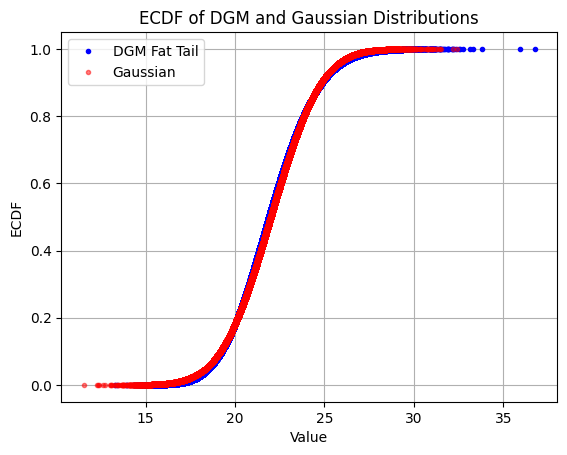

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy.stats import probplot

# Assuming xi_data_frame and gaussian_samples are defined from previous code
n_samples = 250_000
xi_data_list, xi_data_frame = DGM_fat(n_samples, xi_mean, xi_std)
gaussian_samples = np.random.normal(loc=xi_mean, scale=xi_std, size=(n_samples, len(xi_mean)))

# ECDF plot
def ecdf(data):
    """Compute ECDF for a one-dimensional array of measurements."""
    # Number of data points: n
    n = len(data)
    # x-data for the ECDF: x
    x = np.sort(data)
    # y-data for the ECDF: y
    y = np.arange(1, n + 1) / n
    return x, y

x_ecdf, y_ecdf = ecdf(xi_data_frame.iloc[:,0])
x_gauss_ecdf, y_gauss_ecdf = ecdf(pd.DataFrame(gaussian_samples).iloc[:,0])

plt.plot(x_ecdf, y_ecdf, marker='.', linestyle='none', color='blue', label='DGM Fat Tail')
plt.plot(x_gauss_ecdf, y_gauss_ecdf, marker='.', linestyle='none', color='red', alpha=0.5, label='Gaussian')

plt.xlabel('Value')
plt.ylabel('ECDF')
plt.title('ECDF of DGM and Gaussian Distributions')
plt.legend()
plt.grid(True)
plt.show()


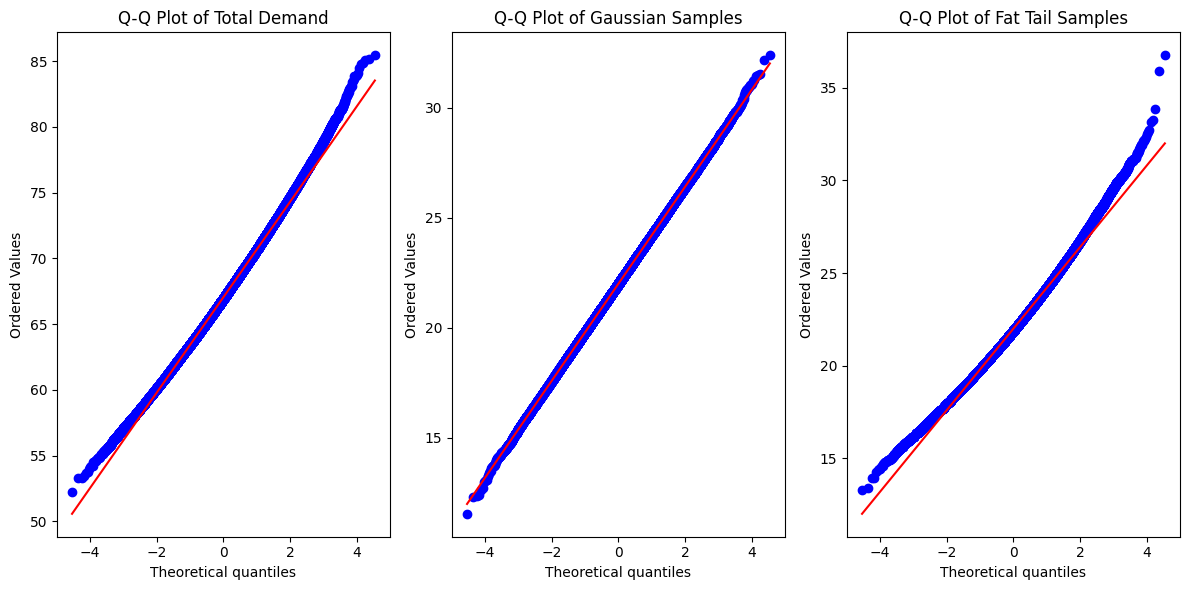

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(12, 6))

# Total demand QQ plot
probplot(total_demand, dist="norm", plot=axes[0])
axes[0].set_title('Q-Q Plot of Total Demand')

# Gaussian samples QQ plot
probplot(pd.DataFrame(gaussian_samples).iloc[:, 0], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot of Gaussian Samples')

# Fat tail samples QQ plot
probplot(xi_data_frame.iloc[:, 0], dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot of Fat Tail Samples')

plt.tight_layout()
plt.show()
